## In-Class Guided Exercise:

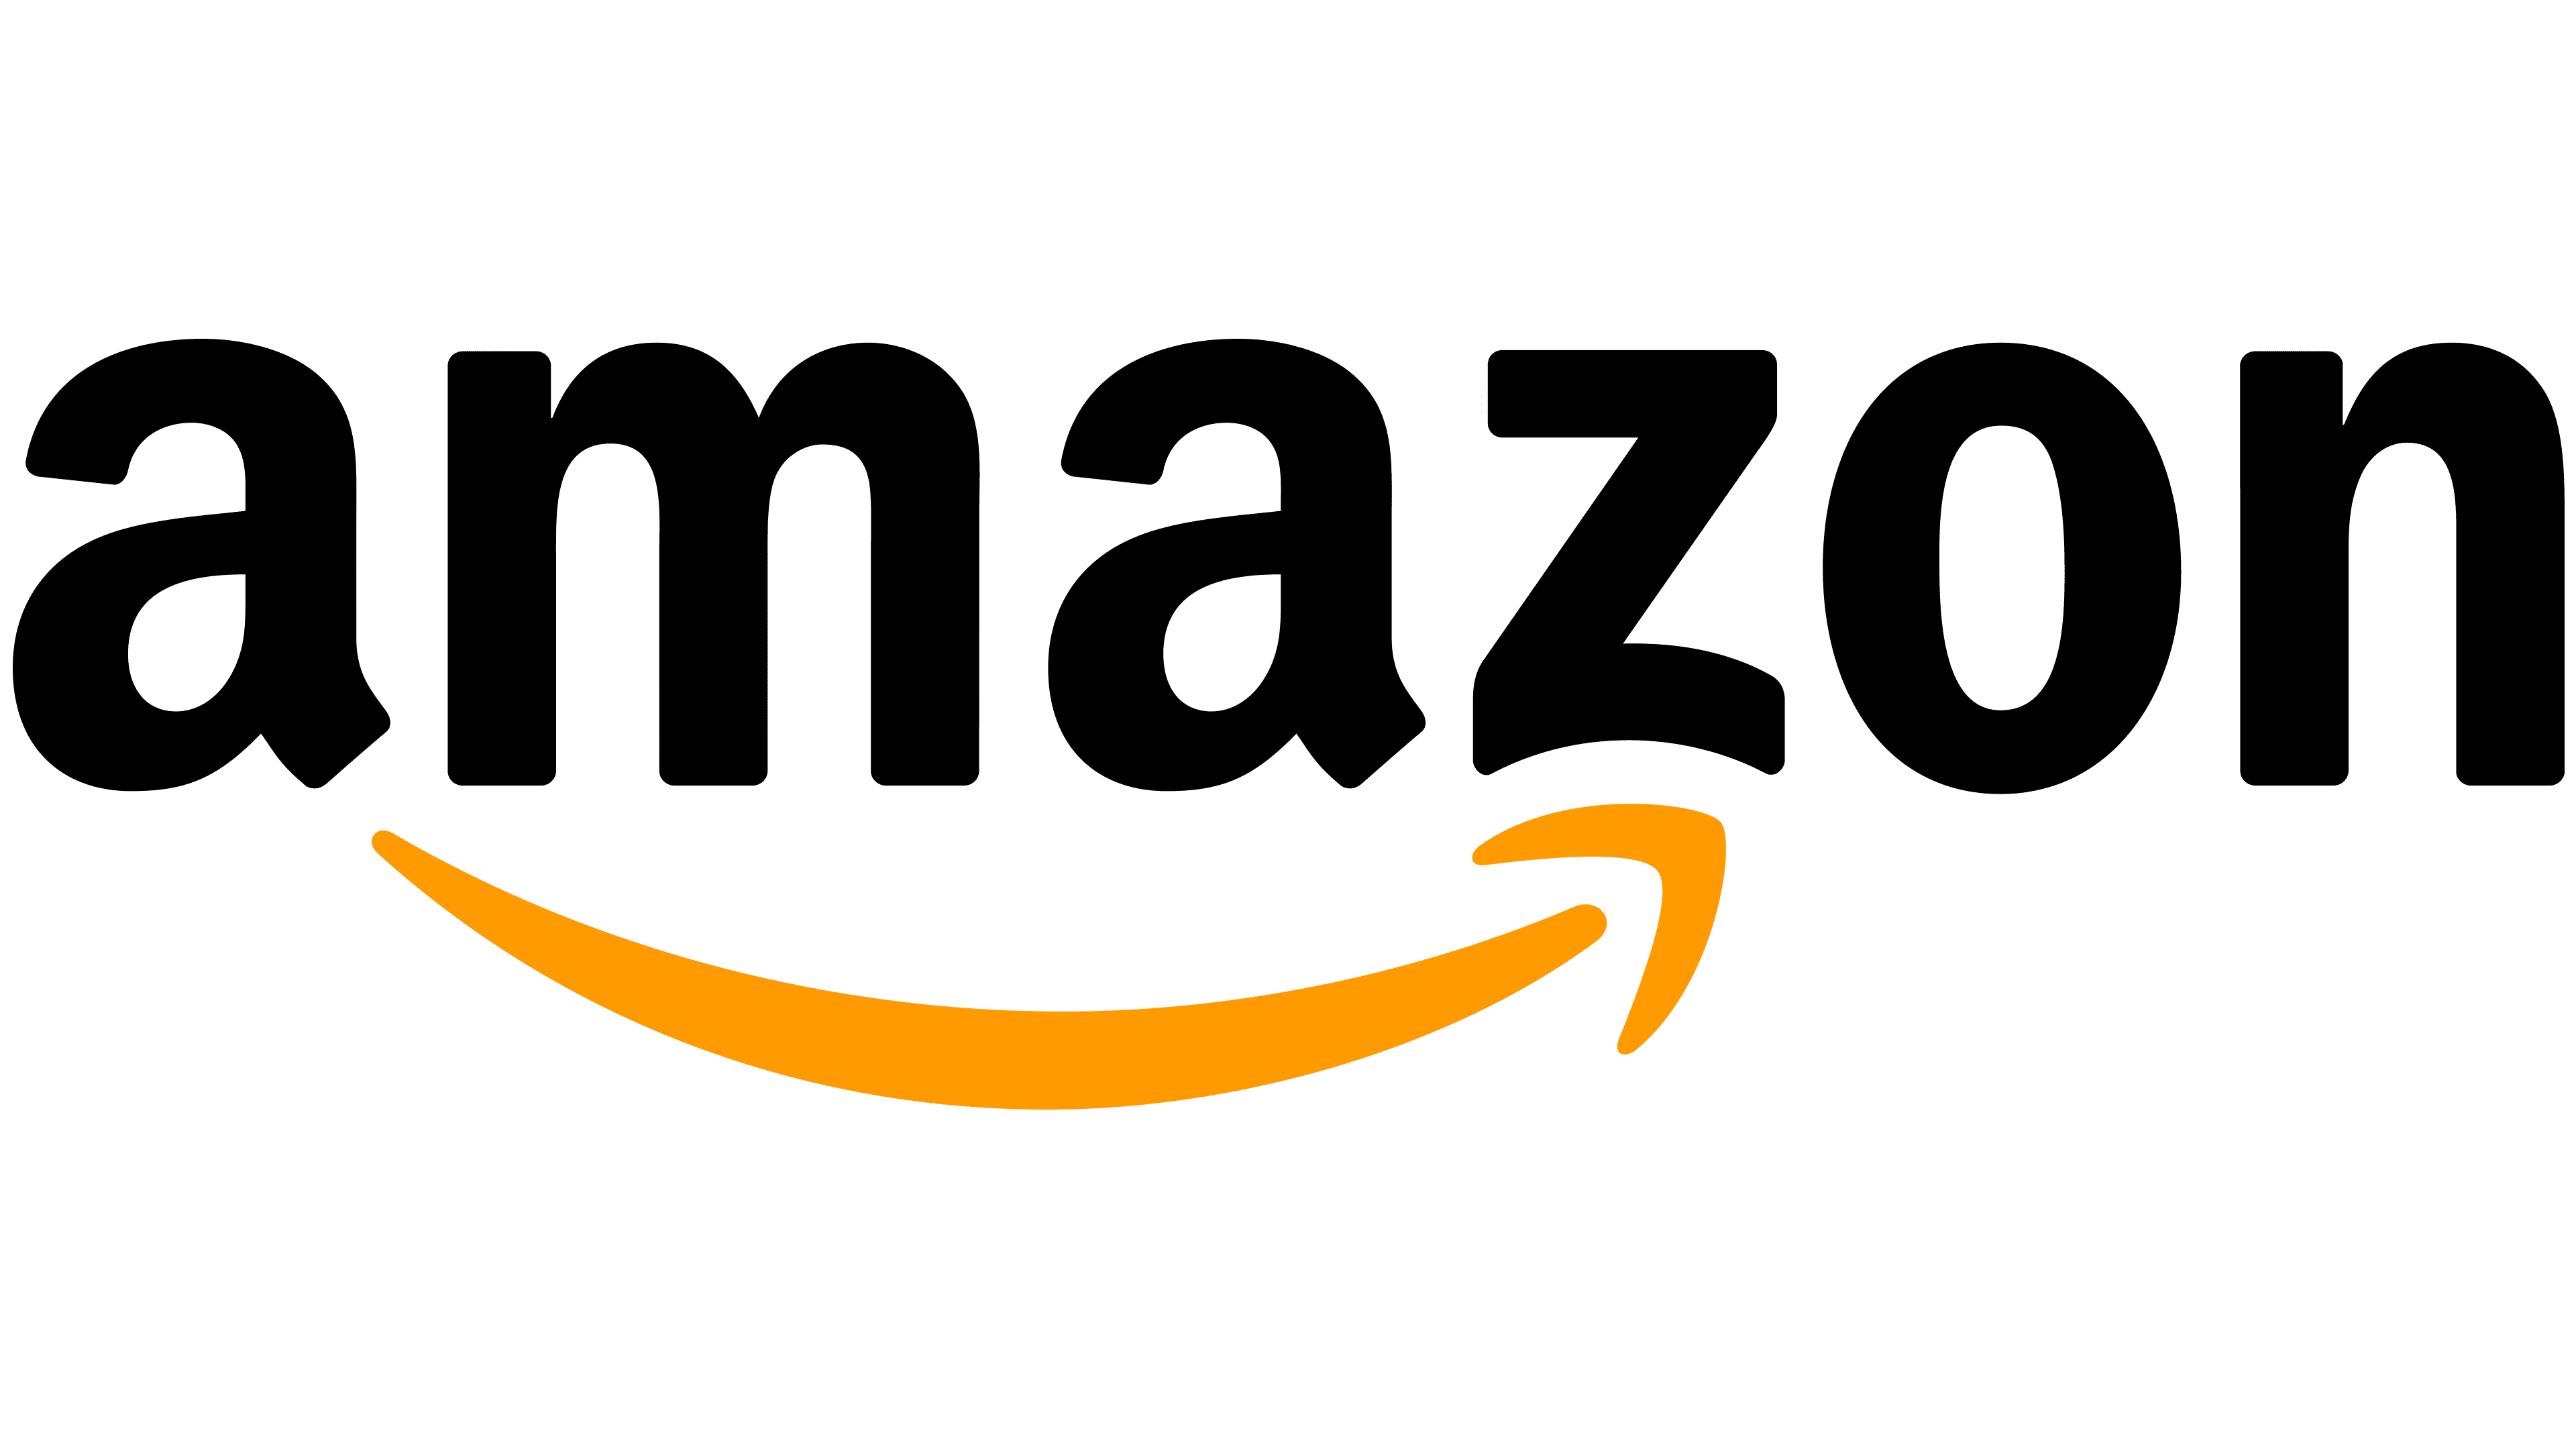



### Import needed libraries

In [9]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep


### Steps on using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [13]:
url="https://www.amazon.sa/-/en/s?k=Computer+Tablets&i=computers&rh=n%3A16966433031&language=en&c=ts&qid=1706531941&ts_id=16966433031&ref=sr_pg_1"
hdr={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.3.0.1922 (beta) Yowser/2.5 Safari/537.3-449"}
html = requests.get(url,headers=hdr)


In [14]:
# Check the status_code
html.status_code
# 200 mean OK 

200

In [15]:
# show the first 2000 characters of the html 
html.text[:2000]

'<!doctype html><html lang="en-ae" class="a-no-js" data-19ax5a9jf="dingo"><!-- sp:feature:head-start -->\n<head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>\n<!-- sp:end-feature:head-start -->\n<!-- sp:feature:csm:head-open-part1 -->\n\n<script type=\'text/javascript\'>var ue_t0=ue_t0||+new Date();</script>\n<!-- sp:end-feature:csm:head-open-part1 -->\n<!-- sp:feature:cs-optimization -->\n<meta http-equiv=\'x-dns-prefetch-control\' content=\'on\'>\n<link rel="preconnect" href="https://images-eu.ssl-images-amazon.com" crossorigin>\n<link rel="preconnect" href="https://m.media-amazon.com" crossorigin>\n<!-- sp:end-feature:cs-optimization -->\n<!-- sp:feature:csm:head-open-part2 -->\n<script type=\'text/javascript\'>\nwindow.ue_ihb = (window.ue_ihb || window.ueinit || 0) + 1;\nif (window.ue_ihb === 1) {\n\nvar ue_csm = window,\n    ue_hob = +new Date();\n(function(d){var e=d.ue=d.ue||{},f=Date.now||function(){return+new Date};e.d=function(b){return f()-

#### 2. Now that we have the web page, we can parse it with beautifulsoup:

In [16]:
soup = BeautifulSoup(html.text, 'html.parser') #<shift + tab> 

- Get the title of the page using the tag 'title':

In [17]:
soup.title.text

'Amazon.sa : Computer Tablets'

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [18]:
# bigger box selection
amazon = soup.find_all('div' ,class_="sg-col-4-of-4 sg-col-4-of-24 sg-col-4-of-12 s-result-item s-asin sg-col-4-of-16 sg-col s-widget-spacing-small sg-col-4-of-8 sg-col-4-of-20")


In [19]:
# Check one of the items collected
amazon[0]

<div class="sg-col-4-of-4 sg-col-4-of-24 sg-col-4-of-12 s-result-item s-asin sg-col-4-of-16 sg-col s-widget-spacing-small sg-col-4-of-8 sg-col-4-of-20" data-asin="B0FQ5XPNH7" data-component-type="s-search-result" data-index="5" data-uuid="533c39f7-8fe4-4d51-849f-934df11f1918" id="533c39f7-8fe4-4d51-849f-934df11f1918" role="listitem"><div class="sg-col-inner"><div cel_widget_id="MAIN-SEARCH_RESULTS-5" class="s-widget-container s-spacing-small s-widget-container-height-small celwidget slot=MAIN template=SEARCH_RESULTS widgetId=search-results_4" data-csa-c-item-id="amzn1.asin.1.B0FQ5XPNH7" data-csa-c-pos="4" data-csa-c-type="item" data-csa-op-log-render=""><span class="a-declarative" data-action="puis-card-container-declarative" data-csa-c-func-deps="aui-da-puis-card-container-declarative" data-csa-c-item-id="amzn1.asin.B0FQ5XPNH7" data-csa-c-owner="puis" data-csa-c-posx="4" data-csa-c-type="item" data-render-id="r3152lce0z4qak2lo5e53z26lbp" data-version-id="v2j36pgodmvsbo2tmbaj1p6v8t0"><

#### 4. Using one item, try to collect the information that you want to scrape
- In our web page here, we want to collect the following:
    - Product Title
    - Link
    - Price
    - Rating
    - Number of Reviews



##### 4.1 *Get the Product Title*

In [20]:
amazon[0].find('h2').text.strip()

'Samsung Galaxy Tab A11, Wifi, Android Tablet, Gray, 8GB RAM, 128GB Storage, 8.7" Screen (KSA Version)'

##### 4.2 *Get the Link*

In [21]:
'https://www.amazon.sa'+ amazon[0].find('a')['href']

'https://www.amazon.sa/-/en/Samsung-Galaxy-Android-Storage-Version/dp/B0FQ5XPNH7/ref=sr_1_4?c=ts&dib=eyJ2IjoiMSJ9.eSSuf18Sf-BXbo6_E3a0DsgRy-lwtdQ8x5wmxxJYep2MHqlna8KJwiKvwSLUHrYM8IGJ1AJeAS5X7oOZ_Igl5YFTAOyUUaikpc6ghVDQcb3WmxwueUWtS-G8-E5R9AR5clzACbpUtG_eTCBP8m9VvAU3iJiQ3uJ8FcGa3N88VTwnp2Om_h33VIpo3_PU4rx9td3ZJ6h6DfMEscnCRiIyMQ-OgGJaNi4l0ZExd2vfqS1dJz_uzZ1BRZo7SplcX2_9r5dtCkkiD4dIpP2CW3FugtwOTvgL6Dfl_8N5wI18I64.1IHdUvbS7ft23T9byvDaj16_A1ywwJ_ZYfo7C5Dyros&dib_tag=se&keywords=Computer+Tablets&qid=1784013007&s=electronics&sr=1-4&ts_id=16966433031'

##### 4.3 *Get the Price*

In [22]:
amazon[0].find('span', class_="a-price-whole").text +amazon[0].find('span', class_="a-price-fraction").text 

'640.53'

##### 4.4 *Get the Rating*

In [23]:
amazon[0].find('span' , class_="a-icon-alt" ).text

'4.4 out of 5 stars'

In [24]:
# getting only the first part of the rating instead of all 
# or you can split it at a later stage
amazon[0].find('span' , class_="a-icon-alt" ).text.split()[0]

'4.4'

##### 4.5 *Get Number of Reviews*

In [ ]:
# same problem you faced in the previous cell will be faced here

In [ ]:
amazon[0].find('span' , class_="a-size-mini puis-normal-weight-text s-underline-text").text.replace('(','').replace(')','')

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- First of all, we need to create a list for each info we want to collect and append the scraped info to those lists

In [27]:
title = []
price = []
rev = []
link_page = []
rating = []

# define the rest of lists to be used to scrape the details of each element
# your code here

for i in amazon:
    try:
        title.append(i.find('h2').text.strip())
    except:
        title.append(None)

    try:
        price.append(i.find('span', class_="a-price-whole").text +i.find('span', class_="a-price-fraction").text )
        
    except:
        price.append(None)

    try:
        rev.append(i.find('span' , class_="a-size-mini puis-normal-weight-text s-underline-text").text)
    except:
        rev.append(None)

    try:
        link_page.append('https://www.amazon.sa'+ i.find('a')['href'])
    except:
        link_page.append(None)

    try:
        rating.append(i.find('span' , class_="a-icon-alt" ).text.split()[0])
    except:
        rating.append(None)

#### 6. Modify the previous `loop` to collect multiple web pages 
- In below code, we collect the web pages from 1 to 5 of that site
- Notice that the only difference from page to page is the page number which we can use in the `for loop` using the curly brackets `{}`

In [38]:
title = []
price = []
rev = []
link_page = []
rating = []

# define the rest of lists to be used to scrape the details of each element

# your code here

for p in range(1,6):
    url = f'https://www.amazon.sa/-/en/s?k=Computer+Tablets&i=computers&rh=n%3A16966433031&language=en&c=ts&qid=1706531941&ts_id=16966433031&ref=sr_pg_{p}'
    link =  requests.get(url)
    soup = BeautifulSoup(link.text, 'html.parser')
    amazon = soup.find_all('div' ,class_="sg-col-4-of-4 sg-col-4-of-24 sg-col-4-of-12 s-result-item s-asin sg-col-4-of-16 sg-col s-widget-spacing-small sg-col-4-of-8 sg-col-4-of-20")
    for i in amazon:
        try:
            title.append(i.find('h2').text.strip())
        except:
            title.append(None)
    
        try:
            price.append(i.find('span', class_="a-price-whole").text +i.find('span', class_="a-price-fraction").text )
        except:
            price.append(None)
    
        try:
            rev.append(i.find('span' , class_="a-size-mini puis-normal-weight-text s-underline-text").text.replace('(','').replace(')',''))
        except:
            rev.append(None)
    
        try:
            link_page.append('https://www.amazon.sa'+ i.find('a')['href'])
        except AttributeError:
            link_page.append(None)
    
        try:
            rating.append(i.find('span' , class_="a-icon-alt" ).text.split()[0])
        except:
            rating.append(None)

#### 7. Create a DataFrame to save all the scraped info. into a table.


In [39]:
amazon_df=pd.DataFrame({
    'Title': title,
    'Price': price,
    'Reviews': rev,
    'Rating': rating,
    'Link': link_page
})


In [40]:
amazon_df

,Title,Price,Reviews,Rating,Link
0,"Samsung Galaxy Tab A11, Wifi, Android Tablet, ...",640.53,110,4.4,https://www.amazon.sa/-/en/Samsung-Galaxy-Andr...
1,HONOR Pad X8b WiFi Tablet 11-Inch 90Hz FHD Dis...,799.00,31,4.1,https://www.amazon.sa/-/en/HONOR-10100mAh-Expa...
2,"Samsung Galaxy Tab A11+, WiFi, Android Tablet,...",799.00,51,4.0,https://www.amazon.sa/-/en/Samsung-Galaxy-Andr...
3,"HUAWEI MatePad SE 11'' 4+128GB Grey Tablet, Fu...",699.00,7,4.0,https://www.amazon.sa/-/en/HUAWEI-MatePad-Full...
4,HUAWEI MatePad SE 11'' 8+128GB Nebula Grey Tab...,799.00,13,4.4,https://www.amazon.sa/-/en/HUAWEI-MatePad-Full...
...,...,...,...,...,...
91,Tablet 2026 World's First Android 16 Tablet wi...,999.99,530,4.5,https://www.amazon.sa/-/en/Android-Display-800...
92,"TABWEE T60 Android 16 Tablet with Keyboard, 12...",899.99,110,4.6,https://www.amazon.sa/-/en/TABWEE-T60-Keyboard...
93,Microsoft (Refurbished) Surface Pro X 2-In-1 L...,"3,299.34",NaN,NaN,https://www.amazon.sa/-/en/Microsoft-Refurbish...
94,10 Inch Android 13 Tablet 12GB RAM+128GB ROM/1...,392.02,1.9K,4.1,https://www.amazon.sa/-/en/Android-Tablet-Expa...


#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [41]:
# Save the output to a csv file (excluding the index)

amazon_df.to_csv("amazon.csv",index=False)